<a href="https://colab.research.google.com/github/grandmeadow/AIFFEL_quest_rs/blob/main/Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

0. 데이터 다운로드

In [1]:
!mkdir -p ~/work/transformer_chatbot/data/ && cd ~/work/transformer_chatbot/data/
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
!pip install sentencepiece
!pip install tensorflow

--2026-06-19 11:18:27--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-06-19 11:18:28--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv’

ChatbotData.csv     100%[===================>] 868.99K  --.-KB/s    in 0.03s   

2026-06-19 11:18:28 (28.7 MB/s) - ‘ChatbotData.csv’ saved [889842/889842]



1. 실습환경 및 라이브러리

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import sentencepiece as spm

import math
import os
import re
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [4]:
# 파일 경로 설정
!wget https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv

# CSV 파일 불러오기
df = pd.read_csv('ChatbotData.csv')

# 샘플 개수 확인
print(f"전체 샘플 개수: {len(df)}개")

# 데이터 확인
df.head()

--2026-06-19 11:19:59--  https://github.com/songys/Chatbot_data/raw/master/ChatbotData.csv
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv [following]
--2026-06-19 11:20:00--  https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 889842 (869K) [text/plain]
Saving to: ‘ChatbotData.csv.2’

ChatbotData.csv.2   100%[===================>] 868.99K  --.-KB/s    in 0.04s   

2026-06-19 11:20:00 (23.0 MB/s) - ‘ChatbotData.csv.2’ saved [889842/889842]

전체 샘플 개수: 11823개


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


2. 전처리

In [5]:
# 텍스트 정제
def preprocess_sentence(sentence):
    # 구두점 기호 양옆에 공백 추가
    sentence = re.sub(f"([?.!,])", r" \1 ", sentence)
    # 공백이 여러 개 연속된 경우 하나로 축소
    sentence = re.sub(r'[" "]+', " ", sentence)
    return sentence.strip()

df['Q'] = df['Q'].apply(preprocess_sentence)
df['A'] = df['A'].apply(preprocess_sentence)

3. 토큰나이징(SentencePiece)

In [6]:
# Q와 A 데이터를 합쳐 하나의 텍스트 파일로 저장
with open('chatbot_corpus.txt', 'w', encoding='utf-8') as f:
    for q, a in zip(df['Q'], df['A']):
        f.write(q + '\n')
        f.write(a + '\n')

# SentencePiece 모델 학습 (Subword 토큰화)
# --input: 학습용 텍스트, --model_prefix: 저장할 모델 이름, --vocab_size: 단어 사전 크기
# pad_id, bos_id, eos_id, unk_id 규칙을 정의합니다.
vocab_size = 8000
spm.SentencePieceTrainer.train(
    '--input=chatbot_corpus.txt --model_prefix=chatbot_spm '
    f'--vocab_size={vocab_size} '
    '--pad_id=0 --bos_id=1 --eos_id=2 --unk_id=3 '
    '--pad_piece=<pad> --bos_piece=<bos> --eos_piece=<eos> --unk_piece=<unk>')

# 학습된 SentencePiece 모델 로드
sp = spm.SentencePieceProcessor()
sp.load('chatbot_spm.model')

True

4. 정수 인코딩 함수

In [7]:
# 토큰화 및 정수 인코딩 함수 정의

# 질문은 인코딩만, 답변은 앞뒤로 문장의 시작(<bos>)과 끝(<eos>) 토큰붙이기
def encode_sentences(questions, answers, sp, max_len=40):
    encoded_questions = []
    encoded_answers = []

    for q, a in zip(questions, answers):
        # 정수 인코딩 및 토큰화
        q_encoded = sp.encode_as_ids(q)
        # 답변의 시작과 끝에 <bos>=1, <eos>=2 추가
        a_encoded = [1] + sp.encode_as_ids(a) + [2]

        # 최대 길이에 맞춰 패딩 (뒤쪽을 0으로 채움)
        if len(q_encoded) < max_len:
            q_encoded += [0] * (max_len - len(q_encoded))
        else:
            q_encoded = q_encoded[:max_len]

        if len(a_encoded) < max_len:
            a_encoded += [0] * (max_len - len(a_encoded))
        else:
            a_encoded = a_encoded[:max_len]

        encoded_questions.append(q_encoded)
        encoded_answers.append(a_encoded)

    return np.array(encoded_questions), np.array(encoded_answers)

# 최종 전처리 데이터
MAX_LENGTH = 40
questions_ready, answers_ready = encode_sentences(df['Q'], df['A'], sp, max_len=MAX_LENGTH)

5. 모델구성

In [8]:
# 1. 포지셔널 인코딩 (Positional Encoding)
class PositionalEncoding(tf.keras.layers.Layer):
    def __init__(self, position, d_model, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.d_model = d_model
        self.position = position
        self.pos_encoding = self.positional_encoding(position, d_model)

    def get_angles(self, position, i, d_model):
        angles = 1 / np.power(10000, (2 * (i // 2)) / np.dtype('float32').type(d_model))
        return position * angles

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(
            position=np.arange(position)[:, np.newaxis],
            i=np.arange(d_model)[np.newaxis, :],
            d_model=d_model)
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = tf.cast(angle_rads, dtype=tf.float32)
        return pos_encoding[tf.newaxis, ...]

    def call(self, inputs):
        # SparseTensor 에러를 방지하기 위해 강제로 일반 텐서 밀집 형태
        if isinstance(inputs, tf.SparseTensor):
            inputs = tf.sparse.to_dense(inputs)
        inputs = tf.cast(inputs, tf.float32)

        seq_len = tf.shape(inputs)[1]
        return inputs + self.pos_encoding[:, :seq_len, :]

  # 케라스에서 아웃풋 형태를 추론하지 못하는 에러 차단
    def compute_output_shape(self, input_shape):
        return input_shape

# 2. 스케일드 닷 프로덕트 어텐션 (Scaled Dot Product Attention)
def scaled_dot_product_attention(query, key, value, mask):
    matmul_qk = tf.matmul(query, key, transpose_b=True)
    depth = tf.cast(tf.shape(key)[-1], tf.float32)
    logits = matmul_qk / tf.math.sqrt(depth)

    if mask is not None:
        logits += (mask * -1e9)

    attention_weights = tf.nn.softmax(logits, axis=-1)
    output = tf.matmul(attention_weights, value)
    return output


# 3. 멀티 헤드 어텐션(Multi-Head Attention)
class MultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % self.num_heads == 0
        self.depth = d_model // self.num_heads
        self.wq = tf.keras.layers.Dense(d_model)
        self.wk = tf.keras.layers.Dense(d_model)
        self.wv = tf.keras.layers.Dense(d_model)
        self.dense = tf.keras.layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, v, k, q, mask):
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        scaled_attention = scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
        return self.dense(concat_attention)


# 4. 마스킹 함수들
def create_padding_mask(x):
    mask = tf.cast(tf.math.equal(x, 0), tf.float32)
    return mask[:, tf.newaxis, tf.newaxis, :]

def create_look_ahead_mask(x):
    seq_len = tf.shape(x)[1]
    look_ahead_mask = 1 - tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
    padding_mask = create_padding_mask(x)
    return tf.maximum(look_ahead_mask, padding_mask)

In [9]:
# 5. 인코더 및 디코더 레이어
def encoder_layer(units, d_model, num_heads, dropout, name="encoder_layer"):
    inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

    attention = MultiHeadAttention(d_model, num_heads)(inputs, inputs, inputs, padding_mask)
    attention = tf.keras.layers.Dropout(rate=dropout)(attention)
    attention = tf.keras.layers.LayerNormalization(epsilon=1e-6)(inputs + attention)

    outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention)
    outputs = tf.keras.layers.Dense(units=d_model)(outputs)
    outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
    outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention + outputs)

    return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

def encoder(vocab_size, num_layers, units, d_model, num_heads, dropout, name="encoder"):
    inputs = tf.keras.Input(shape=(None,), name="inputs", dtype='int32')
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

    embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
    embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
    embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
    outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

    for i in range(num_layers):
        outputs = encoder_layer(units=units, d_model=d_model, num_heads=num_heads,
                                dropout=dropout, name=f"encoder_layer_{i}")([outputs, padding_mask])

    return tf.keras.Model(inputs=[inputs, padding_mask], outputs=outputs, name=name)

def decoder_layer(units, d_model, num_heads, dropout, name="decoder_layer"):
    inputs = tf.keras.Input(shape=(None, d_model), name="inputs")
    enc_outputs = tf.keras.Input(shape=(None, d_model), name="encoder_outputs")
    look_ahead_mask = tf.keras.Input(shape=(1, None, None), name="look_ahead_mask")
    padding_mask = tf.keras.Input(shape=(1, 1, None), name="padding_mask")

    attention1 = MultiHeadAttention(d_model, num_heads)(inputs, inputs, inputs, look_ahead_mask)
    attention1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention1 + inputs)

    attention2 = MultiHeadAttention(d_model, num_heads)(enc_outputs, enc_outputs, attention1, padding_mask)
    attention2 = tf.keras.layers.Dropout(rate=dropout)(attention2)
    attention2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)(attention2 + attention1)

    outputs = tf.keras.layers.Dense(units=units, activation='relu')(attention2)
    outputs = tf.keras.layers.Dense(units=d_model)(outputs)
    outputs = tf.keras.layers.Dropout(rate=dropout)(outputs)
    outputs = tf.keras.layers.LayerNormalization(epsilon=1e-6)(outputs + attention2)

    return tf.keras.Model(inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask], outputs=outputs, name=name)

def decoder(vocab_size, num_layers, units, d_model, num_heads, dropout, name='decoder'):
    inputs = tf.keras.Input(shape=(None,), name='inputs', dtype='int32')
    enc_outputs = tf.keras.Input(shape=(None, d_model), name='encoder_outputs')
    look_ahead_mask = tf.keras.Input(shape=(1, None, None), name='look_ahead_mask')
    padding_mask = tf.keras.Input(shape=(1, 1, None), name='padding_mask')

    embeddings = tf.keras.layers.Embedding(vocab_size, d_model)(inputs)
    embeddings *= tf.math.sqrt(tf.cast(d_model, tf.float32))
    embeddings = PositionalEncoding(vocab_size, d_model)(embeddings)
    outputs = tf.keras.layers.Dropout(rate=dropout)(embeddings)

    for i in range(num_layers):
        outputs = decoder_layer(units=units, d_model=d_model, num_heads=num_heads,
                                dropout=dropout, name=f"decoder_layer_{i}")([outputs, enc_outputs, look_ahead_mask, padding_mask])

    return tf.keras.Model(inputs=[inputs, enc_outputs, look_ahead_mask, padding_mask], outputs=outputs, name=name)


# 6. 최종 트랜스포머 함수
def transformer(vocab_size, num_layers, units, d_model, num_heads, dropout, name="transformer"):
    inputs = tf.keras.Input(shape=(None,), name="inputs", dtype='int32')
    dec_inputs = tf.keras.Input(shape=(None,), name="dec_inputs", dtype='int32')

    enc_padding_mask = tf.keras.layers.Lambda(create_padding_mask, output_shape=(1, 1, None), name='enc_padding_mask')(inputs)
    look_ahead_mask = tf.keras.layers.Lambda(create_look_ahead_mask, output_shape=(1, None, None), name='look_ahead_mask')(dec_inputs)
    dec_padding_mask = tf.keras.layers.Lambda(create_padding_mask, output_shape=(1, 1, None), name='dec_padding_mask')(inputs)

    enc_outputs = encoder(vocab_size=vocab_size, num_layers=num_layers, units=units,
                          d_model=d_model, num_heads=num_heads, dropout=dropout)(inputs=[inputs, enc_padding_mask])

    dec_outputs = decoder(vocab_size=vocab_size, num_layers=num_layers, units=units,
                          d_model=d_model, num_heads=num_heads, dropout=dropout)(inputs=[dec_inputs, enc_outputs, look_ahead_mask, dec_padding_mask])

    outputs = tf.keras.layers.Dense(units=vocab_size, name="outputs")(dec_outputs)

    return tf.keras.Model(inputs=[inputs, dec_inputs], outputs=outputs, name=name)

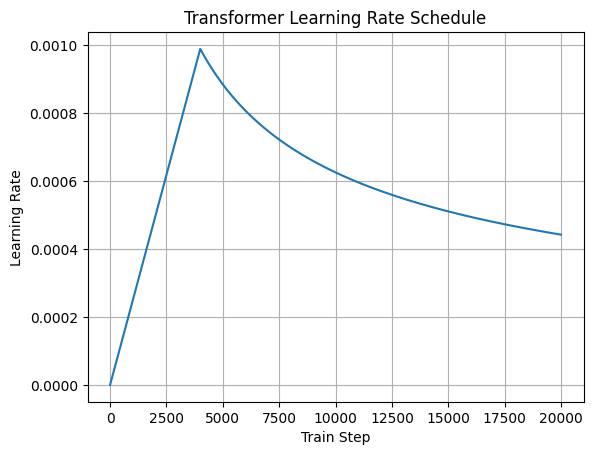

In [10]:
# 학습률 스케줄러
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

# lr 스케줄러 시각화 그래프
D_MODEL = 256
sample_learning_rate = CustomSchedule(d_model=D_MODEL, warmup_steps=4000)

plt.plot(sample_learning_rate(tf.range(20000, dtype=tf.float32)))
plt.ylabel("Learning Rate")
plt.xlabel("Train Step")
plt.title("Transformer Learning Rate Schedule")
plt.grid(True)
plt.show()


**학습률 스케줄러에서 train step 사용 이유**

- 트랜스포머 같은 거대 모델은 1 epoch 도는 데도 수만 번의 가중치 업데이트가 일어남.
- 모델이 망가지지 않게 조심하는 웜업(Warmup)구간은 미세하게 조정되어야 하기 때문에, 덩어리가 큰 Epoch 대신 매 가중치가 바뀔 때마다 정밀하게 학습률을 바꾸기 위해 Train Step 기준으로 그래프를 그리고 조절하는 것임

[참고] 1 step: 하나의 batch를 모델에 넣어 계산하고 가중치를 딱 한 번
업데이트하는 과정
*   1 Epoch = (전체 데이터 개수 / 배치 사이즈) × Train Step




6. 모델학습

In [11]:
# 하이퍼파라미터 정의
VOCAB_SIZE = 8000
NUM_LAYERS = 2
D_MODEL = 256
NUM_HEADS = 8
UNITS = 512
DROPOUT = 0.1

# 모델 초기화
model = transformer(vocab_size=VOCAB_SIZE, num_layers=NUM_LAYERS, units=UNITS,
                    d_model=D_MODEL, num_heads=NUM_HEADS, dropout=DROPOUT)

# 손실 함수 정의 (패딩 마스크 적용)
def loss_function(y_true, y_pred):
    y_true = tf.reshape(y_true, shape=(-1, MAX_LENGTH - 1))
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')(y_true, y_pred)
    mask = tf.cast(tf.math.not_equal(y_true, 0), tf.float32)
    loss = loss * mask
    return tf.reduce_mean(loss)

# 옵티마이저 설정
learning_rate = CustomSchedule(d_model=D_MODEL)
optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

model.compile(optimizer=optimizer, loss=loss_function)

# 이전 단계에서 만든 데이터셋 준비 (디코더 입력은 마지막 eos 토큰 제외, 타겟은 첫 bos 토큰 제외)
# (정제된 questions_ready, answers_ready 배열이 메모리에 있다고 가정합니다.)
X_train = questions_ready
Y_train_in = answers_ready[:, :-1]  # <bos>부터 마지막 전 토큰까지
Y_train_out = answers_ready[:, 1:]  # 첫 토큰 제외하고 <eos>까지

# 학습 시작
BATCH_SIZE = 64
EPOCHS = 15

print("학습 시작~")
model.fit([X_train, Y_train_in], Y_train_out, batch_size=BATCH_SIZE, epochs=EPOCHS)
print("학습 완료!")

학습을 시작합니다...
Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - loss: 1.6987
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 1.3149
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 1.0857
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.9779
Epoch 5/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.8867
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.8073
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.7363
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.6667
Epoch 9/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.5946
Epoch 10/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.5218
Epoch 11/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 0.4479
Epoch 12/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.3755
Epoch 13/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - loss: 0.3074
Epoch 14/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - loss: 0.2488
Epoch 15/15
185/185 ━━━━━━━━

7. 모델평가: 챗봇 테스트

In [17]:
def decoder_inference(sentence, sp, model, max_length=40):
    # 1. 입력 문장 전처리 및 토큰화
    sentence = preprocess_sentence(sentence)
    sentence_encoded = sp.encode_as_ids(sentence)

    # 2. 패딩 추가
    if len(sentence_encoded) < max_length:
        sentence_encoded += [0] * (max_length - len(sentence_encoded))
    else:
        sentence_encoded = sentence_encoded[:max_length]

    inputs = tf.expand_dims(sentence_encoded, axis=0) # 배치 차원 추가

    # 3. 디코더 초깃값으로 <bos>(1) 토큰 설정
    output_sequence = tf.expand_dims([1], axis=0)

    # 4. 루프를 돌며 다음 단어 예측
    for i in range(max_length):
        predictions = model(inputs=[inputs, output_sequence], training=False)
        predictions = predictions[:, -1:, :] # 마지막 타임스텝의 예측값만 가져옴

        predicted_id = tf.cast(tf.argmax(predictions, axis=-1), tf.int32)

        # 만약 모델이 <eos>(2) 토큰을 예측하면 루프 종료
        if tf.equal(predicted_id, 2):
            break

        # 예측된 단어를 디코더 입력 시퀀스에 결합
        output_sequence = tf.concat([output_sequence, predicted_id], axis=-1)

    # 5. 배치를 제거하고 SentencePiece를 이용해 텍스트로 복원
    result_sequence = tf.squeeze(output_sequence, axis=0).numpy().tolist()
    # 첫 <bos>(1) 토큰은 제외하고 디코딩
    decoded_sentence = sp.decode_ids(result_sequence[1:])

    return decoded_sentence

# --- 실전 챗봇 테스트 ---
def ask_chatbot(sentence):
    # 앞서 학습에 썼던 SentencePiece 객체(sp)와 학습 완료된 model을 넣습니다.
    reply = decoder_inference(sentence, sp, model, max_length=MAX_LENGTH)
    print(f"소비자: {sentence}")
    print(f"챗봇: {reply}\n")

# 예시 문장 테스트
ask_chatbot("오늘 무슨 요일이야")
ask_chatbot("나 너무 힘들어.")
ask_chatbot("점심 메뉴 추천해줘.")

소비자: 오늘 무슨 요일이야
챗봇: 마음이 어디를 향하고 있는지 생각해보세요 .

소비자: 나 너무 힘들어.
챗봇: 지금 많이 위축된 상태인 것 같습니다 .

소비자: 점심 메뉴 추천해줘.
챗봇: 맛있는 거 드세요 .



테스트에서 첫 질문과 세번째 질문의 챗봇 답변이 생뚱맞은 이유가 무엇일지 생각해보았다.

* 가장 먼저 떠오른 생각은 학습 데이터셋이 요일을 답변할 수 있는 내용을 포함하고 있지 않아서 그런게 아닐까 유추하였다. 검색해보니 '송영숙 챗봇 데이터'는 고백/이별/일상의 고민을 공감하고 위로해주는 상담용 챗봇이라고 한다. 따라서 질문이 요일, 메뉴 추천과 같은 사실 팩트를 묻는것이라 답변이 이상할 수 밖에 없었을 것이다.

* 두번째는 데이터셋 안에 설령 요일, 음식 메뉴와 관련 질문이 있어더라도 epoch=15로 충분히 학습이 되지 않아서 엉뚱한 답변이 나왔을 가능성도 배제할 수 없다.   